<a href="https://www.kaggle.com/code/lalit7881/ipl-2026-complete-dataset?scriptVersionId=309289189" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/matches.csv
/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/deliveries.csv
/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/points_table.csv
/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/squads.csv
/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/venues.csv
/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/orange_cap.csv
/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/purple_cap.csv


## Loading dataset

In [2]:
matches = pd.read_csv('/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/matches.csv')
deliveries = pd.read_csv('/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/deliveries.csv')
points = pd.read_csv('/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/points_table.csv')
players = pd.read_csv('/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/squads.csv')
venues = pd.read_csv('/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/venues.csv')
orange = pd.read_csv('/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/orange_cap.csv')
purple = pd.read_csv('/kaggle/input/datasets/krishd123/ipl-2026-complete-dataset/purple_cap.csv')

In [3]:
matches.head()
matches.info()
matches.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             7 non-null      int64  
 1   date                 7 non-null      object 
 2   venue                7 non-null      object 
 3   team1                7 non-null      object 
 4   team2                7 non-null      object 
 5   stage                7 non-null      object 
 6   toss_winner          7 non-null      object 
 7   toss_decision        7 non-null      object 
 8   first_ings_score     7 non-null      int64  
 9   first_ings_wkts      7 non-null      int64  
 10  second_ings_score    7 non-null      int64  
 11  second_ings_wkts     7 non-null      int64  
 12  match_result         7 non-null      object 
 13  match_winner         7 non-null      object 
 14  wb_runs              1 non-null      float64
 15  wb_wickets           6 non-null      float64

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,wb_runs,wb_wickets,balls_left,highscore
count,7.000000,7.000000,7.000000,7.000000,7.000000,1.0,6.000000,7.000000,7.000000
mean,4.000000,183.714286,7.428571,176.571429,5.142857,65.0,5.666667,18.857143,68.571429
std,2.160247,39.907035,2.439750,36.050230,2.609506,NaN,1.632993,15.137465,12.025766
min,1.000000,127.000000,4.000000,128.000000,2.000000,65.0,3.000000,5.000000,52.000000
25%,2.500000,151.500000,5.500000,153.000000,4.000000,65.0,5.250000,6.500000,61.000000
50%,4.000000,201.000000,8.000000,165.000000,4.000000,65.0,6.000000,17.000000,72.000000
75%,5.500000,214.500000,9.500000,206.500000,6.000000,65.0,6.000000,25.000000,76.500000
max,7.000000,226.000000,10.000000,224.000000,10.000000,65.0,8.000000,47.000000,81.000000


In [4]:
matches.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_result           0
match_winner           0
wb_runs                6
wb_wickets             1
balls_left             0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

## Total Matches Played by Each Team

In [5]:
team_matches = pd.concat([matches['team1'], matches['team2']])
team_matches.value_counts()

KKR     2
PBKS    2
SRH     2
CSK     2
MI      1
RCB     1
LSG     1
RR      1
GT      1
DC      1
Name: count, dtype: int64

## Most Wins by a Team

In [6]:
matches.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_result', 'match_winner',
       'wb_runs', 'wb_wickets', 'balls_left', 'player_of_the_match',
       'top_scorer', 'highscore', 'best_bowling', 'best_bowling_figure'],
      dtype='object')

In [7]:
toss_win = matches[matches['toss_winner'] == matches['match_winner']]
toss_win_percentage = len(toss_win) / len(matches) * 100

print(toss_win_percentage)

85.71428571428571


In [8]:
matches[['toss_winner', 'match_winner']].head()

,toss_winner,match_winner
0,RCB,RCB
1,MI,MI
2,RR,RR
3,PBKS,PBKS
4,DC,DC


In [9]:
matches['toss_decision'].value_counts()

toss_decision
Bowl    7
Name: count, dtype: int64

In [10]:
toss_win_count = (matches['toss_winner'] == matches['match_winner']).sum()
total_matches = len(matches)

print("Toss Win %:", (toss_win_count / total_matches) * 100)

Toss Win %: 85.71428571428571


In [11]:
pd.crosstab(matches['toss_decision'], 
            matches['toss_winner'] == matches['match_winner'])

col_0,False,True
toss_decision,,
Bowl,1,6


In [12]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['match_winner']

matches.groupby('toss_decision')['toss_win_match_win'].mean() * 100

toss_decision
Bowl    85.714286
Name: toss_win_match_win, dtype: float64

## EDA

In [13]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

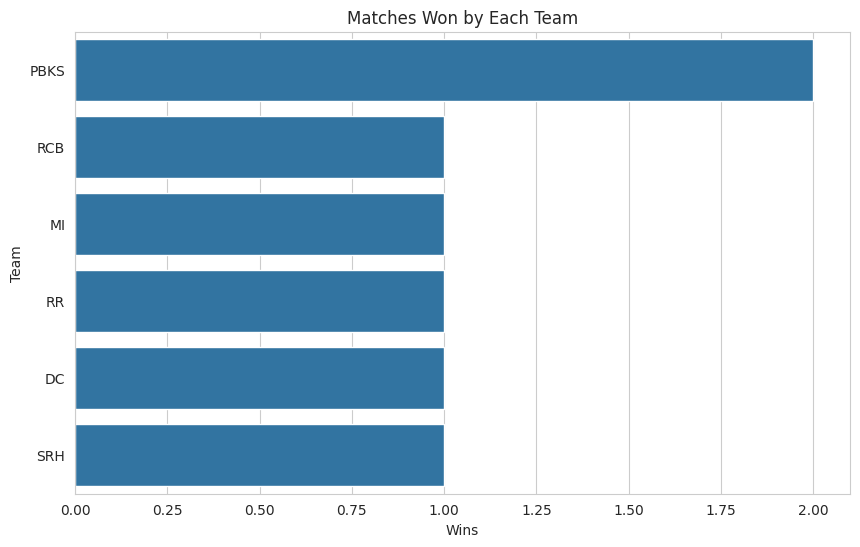

In [14]:
winner_counts = matches['match_winner'].value_counts()

plt.figure()
sns.barplot(x=winner_counts.values, y=winner_counts.index)
plt.title("Matches Won by Each Team")
plt.xlabel("Wins")
plt.ylabel("Team")
plt.show()

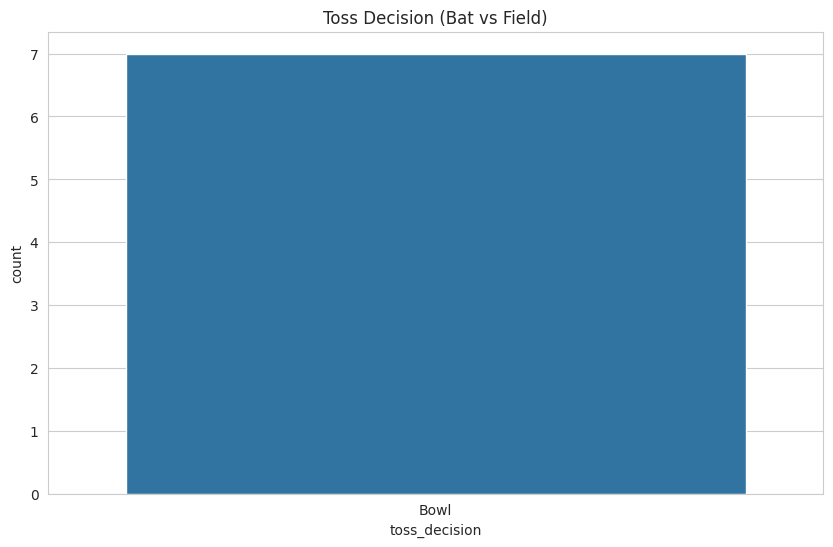

In [15]:
plt.figure()
sns.countplot(x='toss_decision', data=matches)
plt.title("Toss Decision (Bat vs Field)")
plt.show()

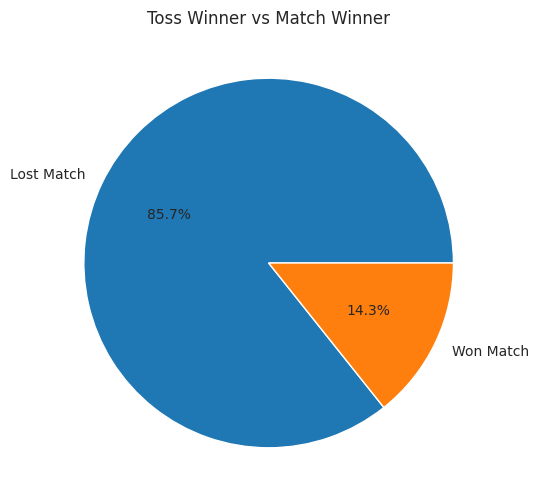

In [16]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['match_winner']

toss_result = matches['toss_win_match_win'].value_counts()

plt.figure()
plt.pie(toss_result, labels=['Lost Match', 'Won Match'], autopct='%1.1f%%')
plt.title("Toss Winner vs Match Winner")
plt.show()

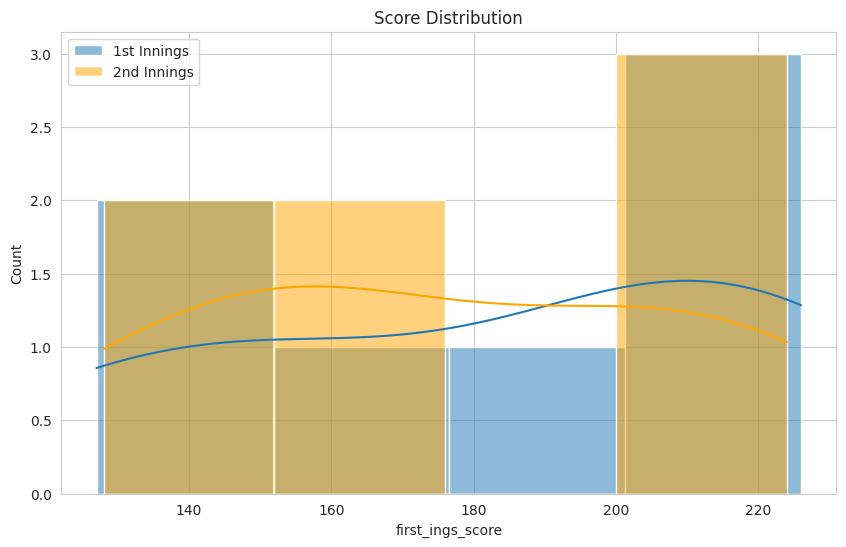

In [17]:
plt.figure()
sns.histplot(matches['first_ings_score'], kde=True, label='1st Innings')
sns.histplot(matches['second_ings_score'], kde=True, color='orange', label='2nd Innings')
plt.legend()
plt.title("Score Distribution")
plt.show()

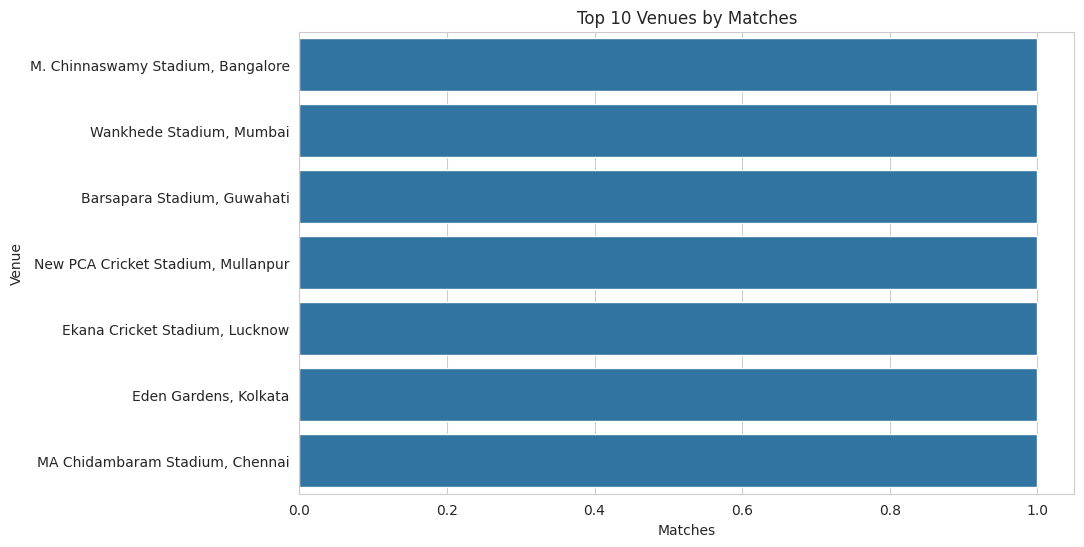

In [18]:
venue_counts = matches['venue'].value_counts().head(10)

plt.figure()
sns.barplot(x=venue_counts.values, y=venue_counts.index)
plt.title("Top 10 Venues by Matches")
plt.xlabel("Matches")
plt.ylabel("Venue")
plt.show()

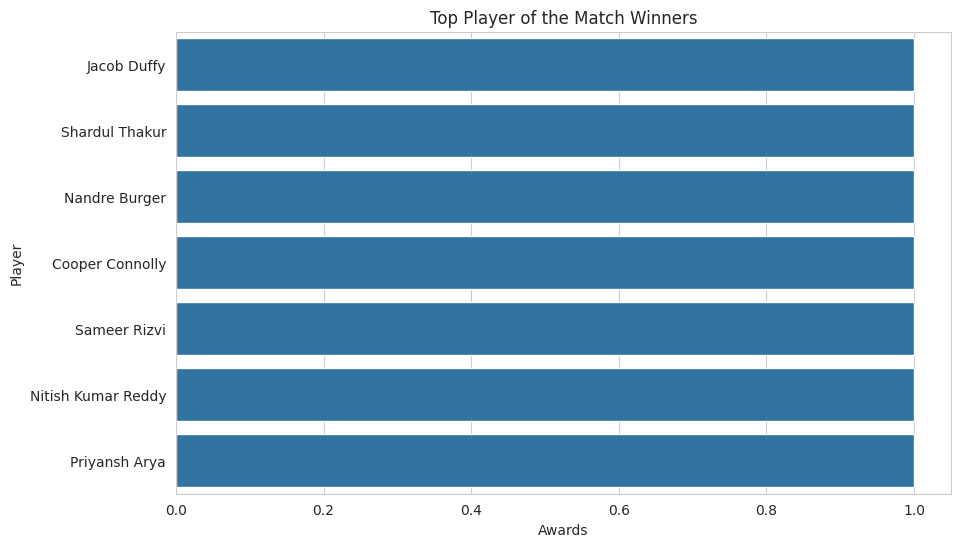

In [19]:
pom = matches['player_of_the_match'].value_counts().head(10)

plt.figure()
sns.barplot(x=pom.values, y=pom.index)
plt.title("Top Player of the Match Winners")
plt.xlabel("Awards")
plt.ylabel("Player")
plt.show()

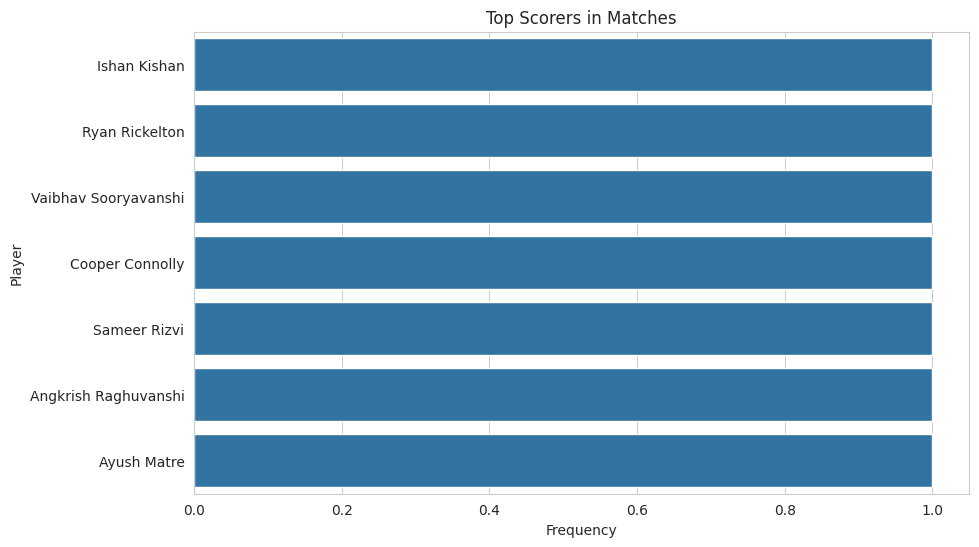

In [20]:
top_scorers = matches['top_scorer'].value_counts().head(10)

plt.figure()
sns.barplot(x=top_scorers.values, y=top_scorers.index)
plt.title("Top Scorers in Matches")
plt.xlabel("Frequency")
plt.ylabel("Player")
plt.show()

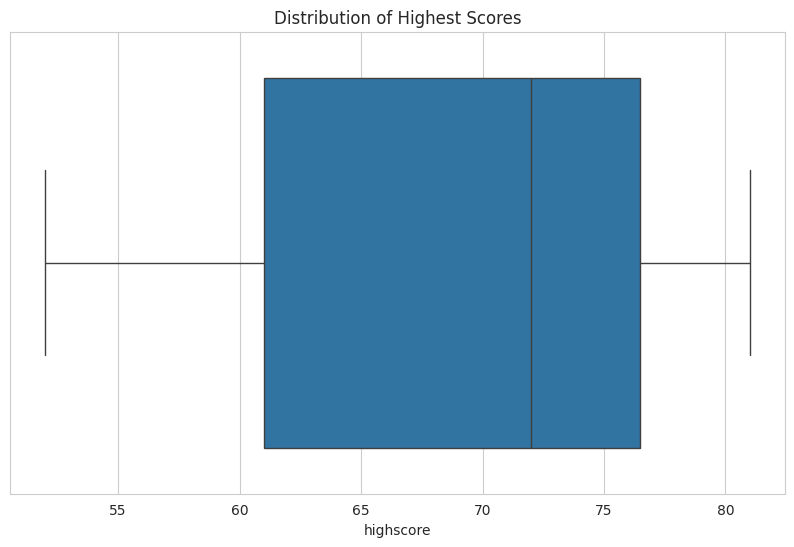

In [21]:
plt.figure()
sns.boxplot(x=matches['highscore'])
plt.title("Distribution of Highest Scores")
plt.show()

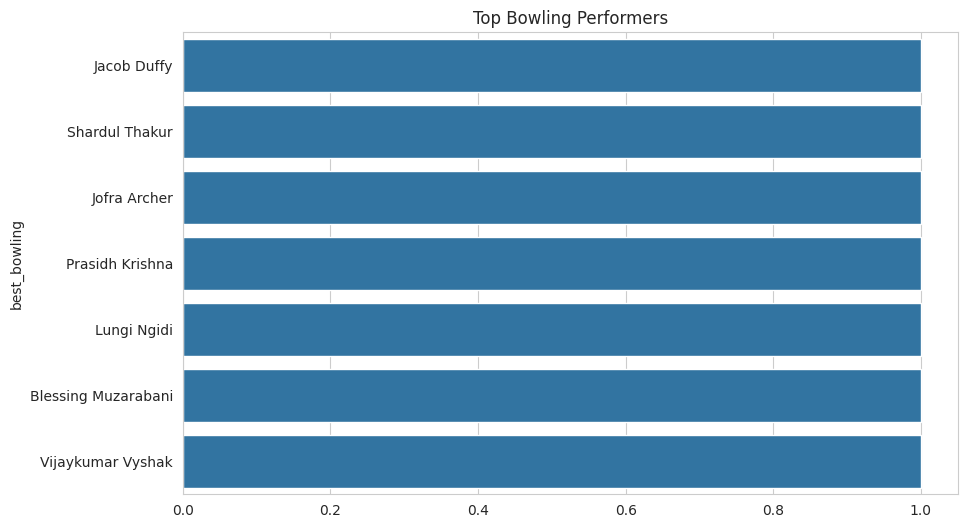

In [22]:
best_bowlers = matches['best_bowling'].value_counts().head(10)

plt.figure()
sns.barplot(x=best_bowlers.values, y=best_bowlers.index)
plt.title("Top Bowling Performers")
plt.show()

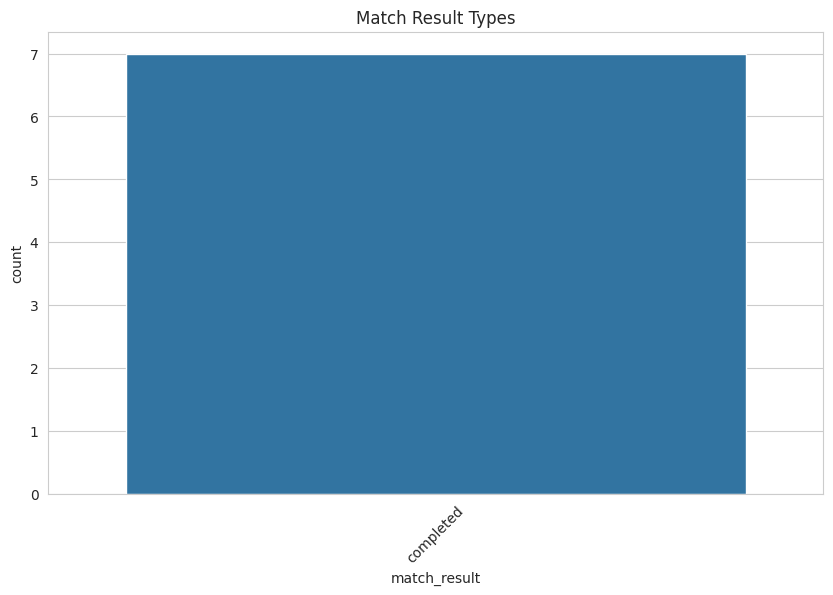

In [23]:
plt.figure()
sns.countplot(x='match_result', data=matches)
plt.title("Match Result Types")
plt.xticks(rotation=45)
plt.show()

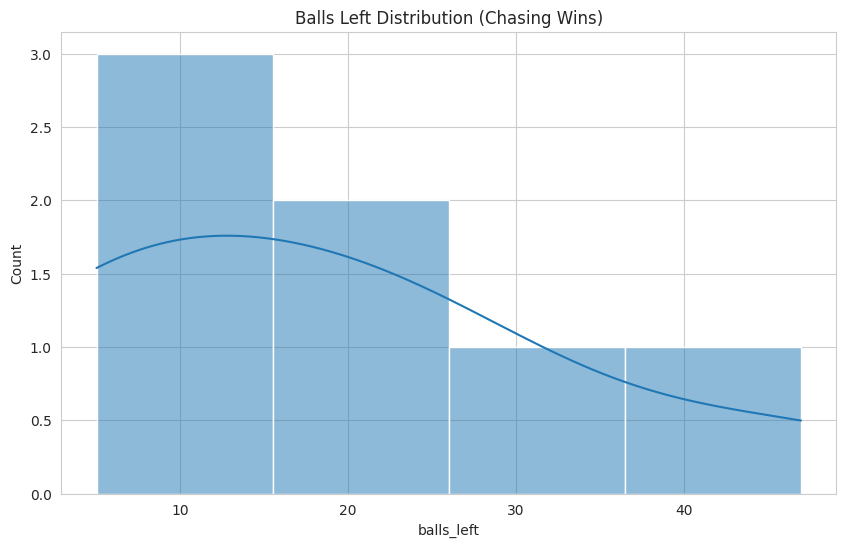

In [24]:
plt.figure()
sns.histplot(matches['balls_left'], kde=True)
plt.title("Balls Left Distribution (Chasing Wins)")
plt.show()

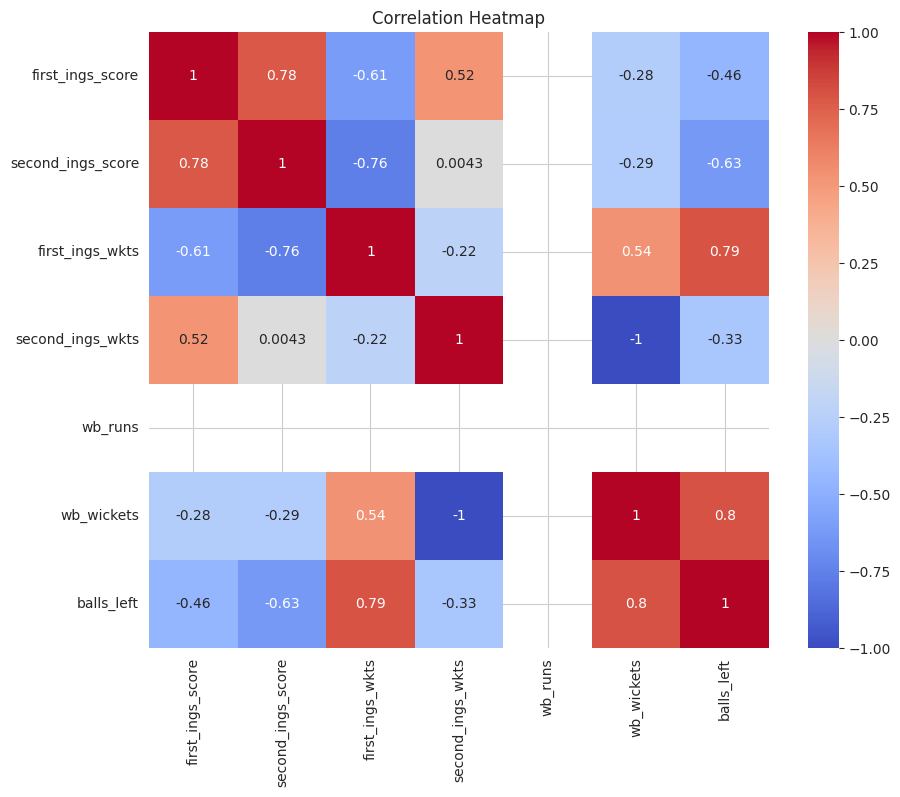

In [25]:
numeric_cols = ['first_ings_score', 'second_ings_score', 
                'first_ings_wkts', 'second_ings_wkts',
                'wb_runs', 'wb_wickets', 'balls_left']

plt.figure(figsize=(10,8))
sns.heatmap(matches[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

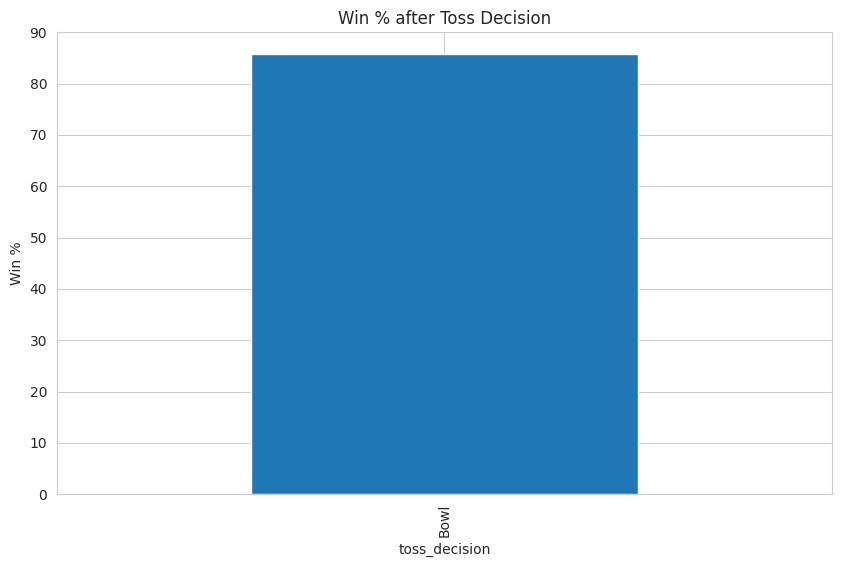

In [26]:
win_by_decision = matches.groupby('toss_decision')['toss_win_match_win'].mean() * 100

plt.figure()
win_by_decision.plot(kind='bar')
plt.title("Win % after Toss Decision")
plt.ylabel("Win %")
plt.show()

## Feature engineering

Train size: 4
Test size: 3
Accuracy: 0.3333333333333333
ROC not possible: Only one class in test data


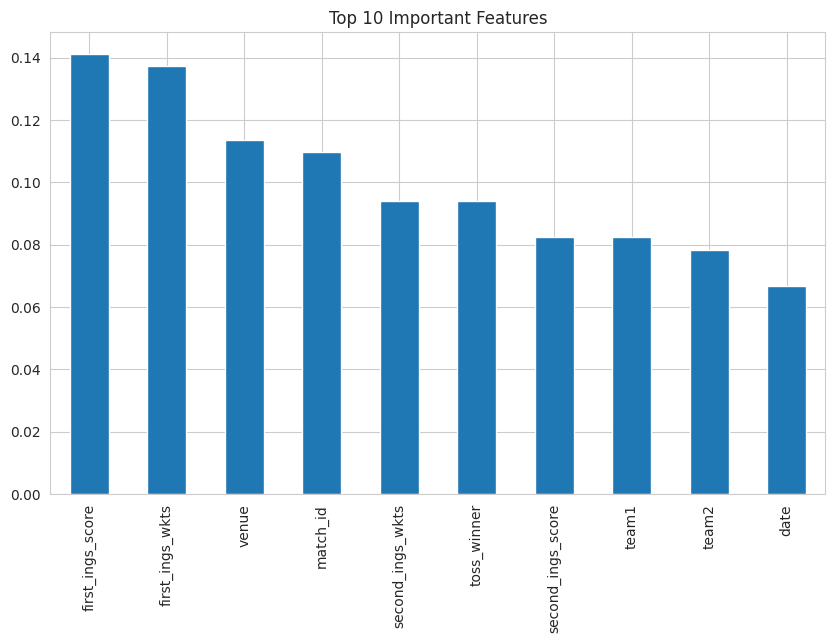

In [27]:
# ================================
# 1. IMPORT LIBRARIES
# ================================


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier


# ================================
# 2. LOAD DATA
# ================================
df = matches.copy()


# ================================
# 3. CONVERT TO BINARY TARGET
# (Example: PBKS vs Others)
# ================================
y = df['match_winner'].apply(lambda x: 1 if x == 'PBKS' else 0)


# ================================
# 4. DROP LEAKAGE COLUMNS
# ================================
X = df.drop(columns=[
    'match_winner',
    'wb_runs', 'wb_wickets', 'balls_left',
    'player_of_the_match', 'top_scorer',
    'highscore', 'best_bowling', 'best_bowling_figure'
])


# ================================
# 5. HANDLE MISSING VALUES
# ================================
X = X.fillna("Unknown")


# ================================
# 6. LABEL ENCODING
# ================================
le_dict = {}

for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        le_dict[col] = le


# ================================
# 7. TRAIN-TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


# ================================
# 8. TRAIN MODEL
# ================================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


# ================================
# 9. PREDICTIONS + ACCURACY
# ================================
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


# ================================
# 10. ROC CURVE (VALID NOW ✅)
# ================================
# Only works if both classes present in test
if len(np.unique(y_test)) == 2:
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (Binary Classification)")
    plt.legend()
    plt.show()
else:
    print("ROC not possible: Only one class in test data")


# ================================
# 11. FEATURE IMPORTANCE (BONUS 🔥)
# ================================
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure()
importances.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()